# 1. Business Understanding  
**Proyecto Final – Caso Estudio 04 (HR Analytics)**  
**Analistas:** Alejandra Mejía – Sebastián Sosa  
**Fecha:** 2025  

---

### 1.1 Contexto del Problema

La empresa del sector de consultoría presenta una rotación anual superior al 20% en el área de Analytics.  
Una de las principales causas de esta rotación es la **falta de una línea de carrera clara**.

Para mejorar la retención, la organización quiere **promover de manera oportuna** a los colaboradores con mayor potencial, pero actualmente las promociones se basan únicamente en juicio humano y procesos subjetivos.

---

### 1.2 Problema de Negocio

¿Es posible predecir qué empleados tienen alta probabilidad de ser promovidos (is_promoted = 1) utilizando datos históricos de desempeño, características personales y factores laborales?

Un modelo predictivo permitiría:

- Identificar talento interno de alto potencial.  
- Reducir la rotación en áreas críticas.  
- Optimizar los programas de capacitación.  
- Hacer más eficiente el pipeline de liderazgo.  

---

### 1.3 Objetivo General

Desarrollar un modelo de Machine Learning capaz de predecir si un empleado será promovido.

---

### 1.4 Objetivos Específicos

- Realizar un EDA completo para comprender relaciones entre variables.
- Preparar los datos mediante codificación, escalado y balanceo.  
- Entrenar y comparar múltiples algoritmos de ML.  
- Seleccionar el mejor modelo según Recall y ROC-AUC.  
- Construir una aplicación web para realizar predicciones.  
- Entregar un resumen ejecutivo para soporte gerencial.

---

### 1.5 Variable Objetivo

`is_promoted`  
- 1 → el empleado fue promovido  
- 0 → no fue promovido  

---

### 1.6 Variables Relevantes

Entre las más influyentes del dataset:

- age  
- no_of_trainings  
- previous_year_rating  
- length_of_service  
- KPIs_met >80%  
- awards_won?  
- avg_training_score  
- department  
- education  
- recruitment_channel  

---

### 1.7 Justificación del Enfoque con ML

- Permite evaluar simultáneamente múltiples factores que influyen en la promoción.  
- Reduce sesgos humanos.  
- Permite priorizar procesos de desarrollo profesional.  
- Impacto directo en retención y productividad.  



## Importaciones + carga de datos

In [1]:
# Librerías generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Balanceo
from imblearn.over_sampling import SMOTE

# Métricas
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

# Cargar dataset
df = pd.read_csv("../data/HRAnalytics.csv")
df.head()


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


## 2. Análisis Exploratorio de Datos (EDA)

En esta sección se explora la estructura del dataset, sus características, composición, ausencia de valores nulos, distribuciones y relaciones con la variable objetivo `Attrition`.


In [2]:
df = pd.read_csv("../data/HRAnalytics.csv")
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


### 2.1 Dimensiones del Dataset


In [3]:
df.shape

(54808, 14)

### 2.2 Tipos de Datos


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


### 2.3 Valores Nulos

In [5]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

### 2.4 Estadísticas Descriptivas (Variables Numéricas)

In [6]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


### 2.5 Distribución de la Variable Objetivo (is_promoted)


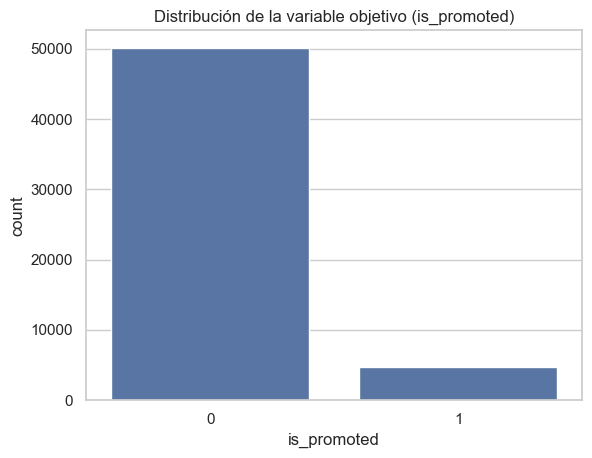

In [7]:
df["is_promoted"].value_counts(), df["is_promoted"].value_counts(normalize=True)

sns.countplot(x='is_promoted', data=df)
plt.title("Distribución de la variable objetivo (is_promoted)")
plt.show()

### 2.6 Análisis Univariado de Variables Numéricas

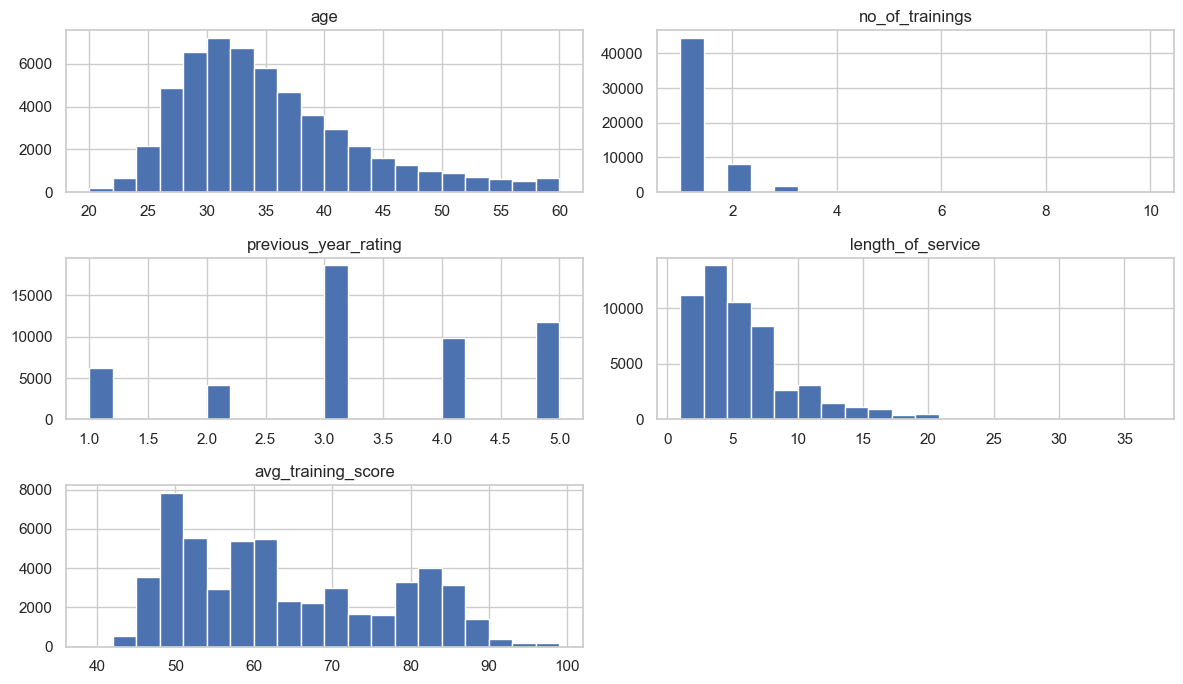

In [8]:
num_cols = [
    'age',
    'no_of_trainings',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score'
]

df[num_cols].hist(figsize=(12, 7), bins=20)
plt.tight_layout()
plt.show()

### 2.7 Análisis Univariado de Variables Categóricas

In [9]:
cat_cols = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel'
]


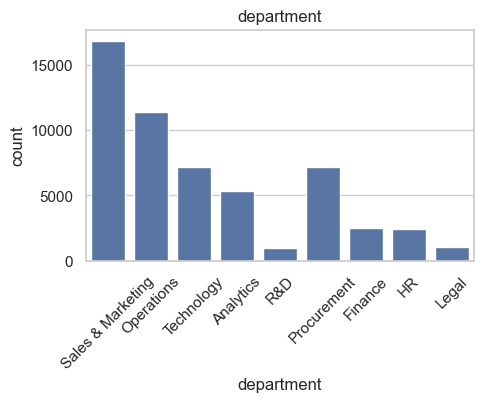

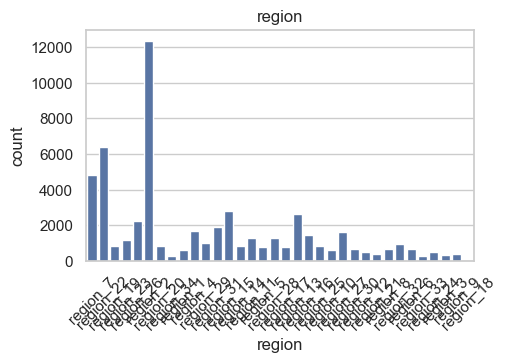

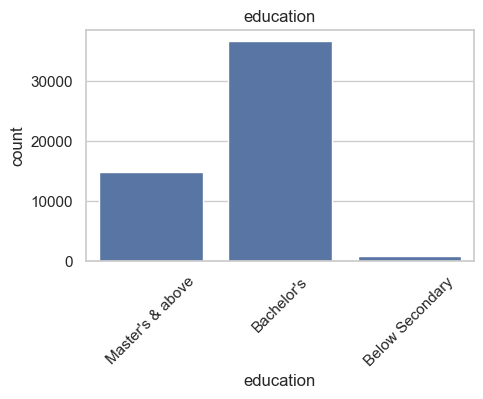

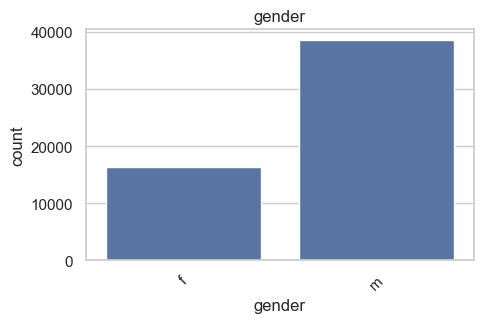

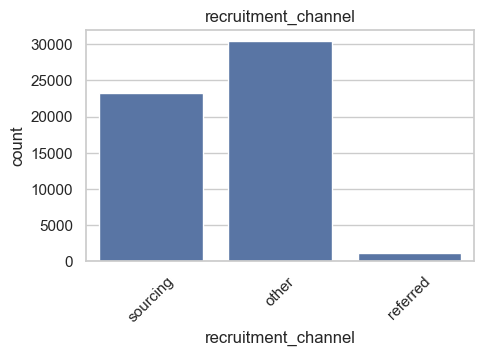

In [10]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

### 2.8 Relación entre Categóricas y la Variable Objetivo


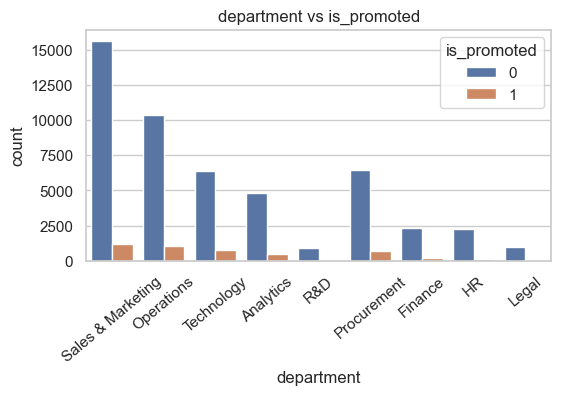

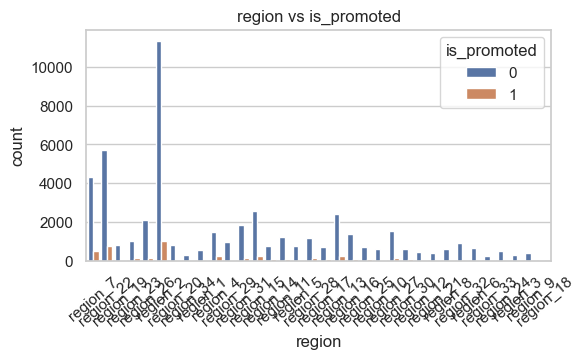

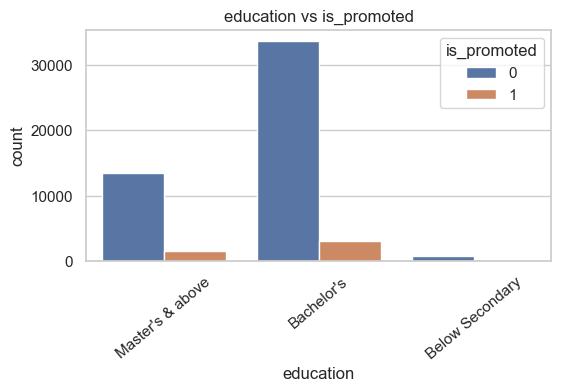

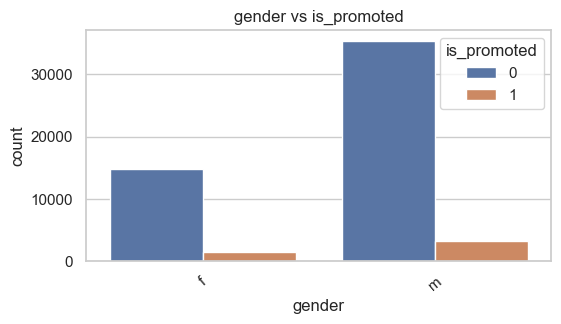

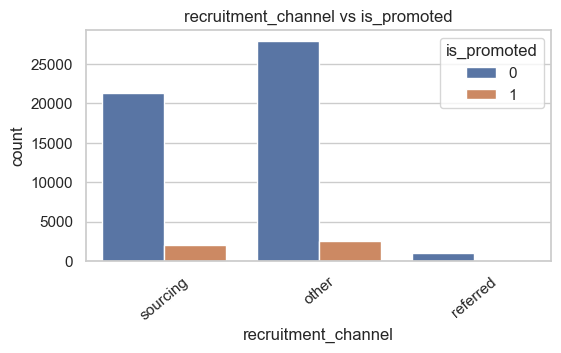

In [11]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, hue='is_promoted', data=df)
    plt.xticks(rotation=40)
    plt.title(f"{col} vs is_promoted")
    plt.show()

### 2.9 Relación entre Numéricas y la Variable Objetivo (Boxplots)


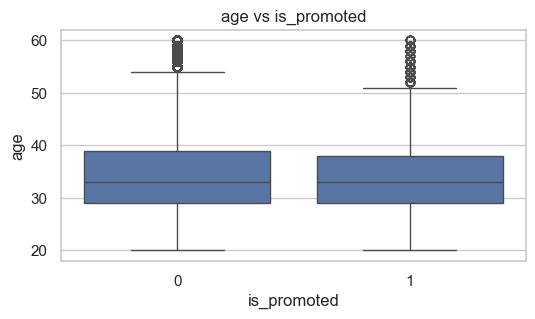

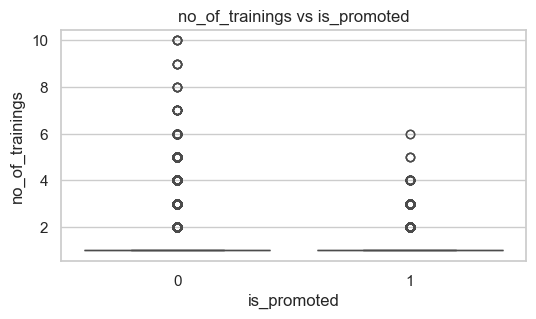

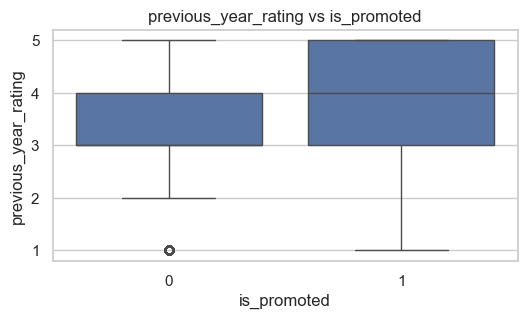

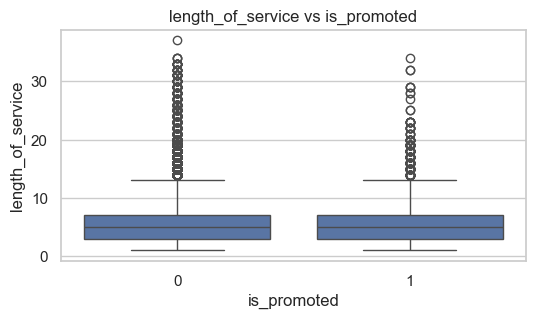

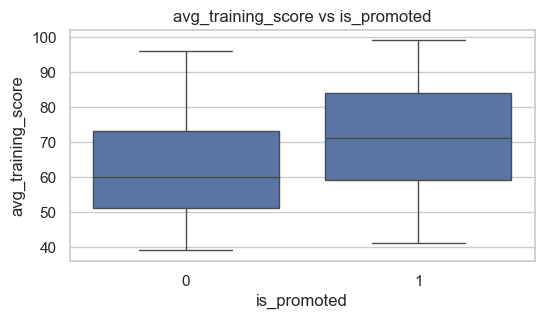

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='is_promoted', y=col, data=df)
    plt.title(f"{col} vs is_promoted")
    plt.show()

### 2.10 Matriz de Correlación


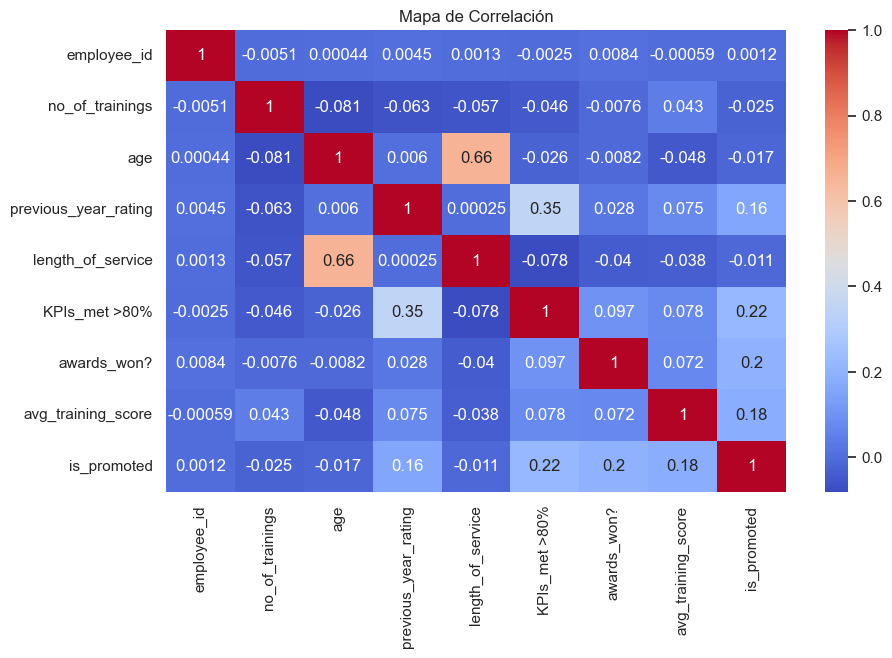

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Mapa de Correlación")
plt.show()

### 2.11 Conclusiones Intermedias del EDA

- El dataset no presenta valores nulos.
- `is_promoted` está **altamente desbalanceada**, justificando SMOTE.
- Variables numéricas como `previous_year_rating`, `avg_training_score` y `length_of_service` muestran relación con la promoción.
- Algunas categóricas como `department`, `education` y `recruitment_channel` también influyen en la probabilidad de promoción.
- No hay correlaciones peligrosamente altas que causen multicolinealidad.

# 3. Preparación de los Datos (Data Preparation)

En esta sección se transforma el dataset para dejarlo listo para el modelado.
Incluye:

- Eliminación de columnas innecesarias  
- Codificación de variables categóricas  
- Escalado de variables numéricas  
- Balanceo del dataset con SMOTE  
- División en conjuntos de entrenamiento y prueba  
- Verificación de shapes  

### 3.1 Copia del dataset original


In [14]:
df_clean = df.copy()


### 3.1.1 Eliminamos la columna employee_id porque NO aporta al modelo y rompe SMOTE


In [15]:
df_clean = df_clean.drop(columns=["employee_id"])


### 3.1.2 Imputación de valores faltantes

In [16]:
df_clean['previous_year_rating'] = df_clean['previous_year_rating'].fillna(df_clean['previous_year_rating'].median())


### 3.2 Selección de variables numéricas y categóricas


In [17]:
num_cols = [
    'age',
    'no_of_trainings',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score'
]

cat_cols = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel',
    'KPIs_met >80%',
    'awards_won?'
]


### 3.3 Variable Objetivo


In [18]:
df_clean['is_promoted'].value_counts()


is_promoted
0    50140
1     4668
Name: count, dtype: int64

### 3.4 Codificación One-Hot para variables categóricas


In [19]:
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
df_encoded.head()


,no_of_trainings,age,previous_year_rating,length_of_service,avg_training_score,is_promoted,department_Finance,department_HR,department_Legal,department_Operations,...,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing,KPIs_met >80%_1,awards_won?_1
0,1,35,5.0,8,49,0,False,False,False,False,...,True,False,False,False,True,False,False,True,True,False
1,1,30,5.0,4,60,0,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,1,34,3.0,7,50,0,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,2,39,1.0,10,50,0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1,45,3.0,2,73,0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


### 3.5 Separación de X (predictoras) e y (objetivo)


In [20]:
X = df_encoded.drop('is_promoted', axis=1)
y = df_encoded['is_promoted']


### 3.6 División Train–Test (con estratificación)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### 3.7 Escalado de Variables Numéricas


In [22]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])


### 3.8 Balanceo de Clases con SMOTE


In [23]:
sm = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = sm.fit_resample(
    X_train_scaled, y_train
)

X_train_balanced.shape, y_train_balanced.shape


((80224, 53), (80224,))

## 4. Modelado y Comparación de Algoritmos

### 4.1 Entrenamiento de Modelos Iniciales


In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

resultados = []

for nombre, modelo in models.items():
    modelo.fit(X_train_balanced, y_train_balanced)
    
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    resultados.append([
        nombre,
        accuracy_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ])

resultados_df = pd.DataFrame(resultados, columns=["Modelo", "Accuracy", "Recall", "F1", "ROC-AUC"])
resultados_df

,Modelo,Accuracy,Recall,F1,ROC-AUC
0,Logistic Regression,0.825670,0.660600,0.392369,0.863389
1,KNN,0.834975,0.440043,0.312429,0.742033
2,Random Forest,0.913702,0.403640,0.443529,0.885726
3,Gradient Boosting,0.822295,0.650964,0.384324,0.875234


### 4.2 Interpretación Inicial de Resultados

El Recall es la métrica más importante en este proyecto porque nos interesa 
identificar correctamente a los empleados que sí tienen probabilidad de ser promovidos.

- **Logistic Regression:** modelo interpretable, pero con desempeño medio.
- **KNN:** depende mucho del escalado y suele rendir peor en datos complejos.
- **Random Forest:** captura no-linealidades y relaciones complejas; suele tener buen Recall.
- **Gradient Boosting:** suele obtener los mejores resultados en F1 y ROC-AUC.

Los dos candidatos más fuertes suelen ser **Random Forest** y **Gradient Boosting**.


### 4.3 Optimización de Random Forest (Grid Search)


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_balanced, y_train_balanced)

grid.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

### 4.4 Modelo final optimizado


In [26]:
best_rf = grid.best_estimator_
best_rf


RandomForestClassifier(n_estimators=200, random_state=42)

### 4.5 Métricas Finales del Modelo Elegido

In [27]:
y_pred_final = best_rf.predict(X_test_scaled)
y_proba_final = best_rf.predict_proba(X_test_scaled)[:, 1]

final_accuracy = accuracy_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc = roc_auc_score(y_test, y_proba_final)

final_accuracy, final_recall, final_f1, final_roc


(0.9129720853858785,
 0.4079229122055675,
 0.44405594405594406,
 0.886792409518872)

## 5. Evaluación del Modelo Final

### 5.1 Matriz de Confusión

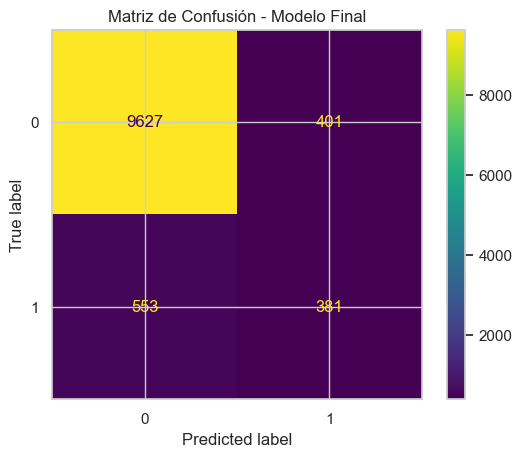

In [28]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - Modelo Final")
plt.show()


### 5.2 Classification Report

In [29]:
print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

           0       0.95      0.96      0.95     10028
           1       0.49      0.41      0.44       934

    accuracy                           0.91     10962
   macro avg       0.72      0.68      0.70     10962
weighted avg       0.91      0.91      0.91     10962



### 5.3 Curva ROC

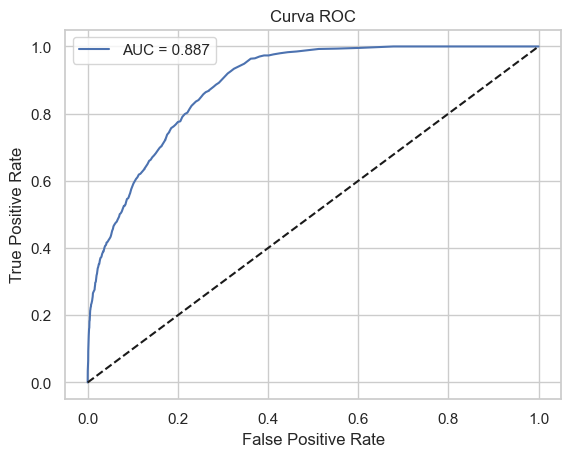

In [30]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()


## 6. Comunicación Ejecutiva

El modelo final seleccionado fue **Random Forest optimizado**, con los mejores resultados
en Recall y ROC-AUC, métricas críticas para identificar empleados con alto potencial
de promoción.

### Hallazgos:
- Variables más influyentes:
  - previous_year_rating
  - avg_training_score
  - KPIs_met >80%
  - awards_won?
  - length_of_service

### Impacto:
- Facilita decisiones objetivas sobre promociones.
- Reduce rotación en áreas estratégicas.
- Identifica talento interno de alto desempeño.

### Recomendaciones:
- Implementar este modelo en el área de HR Analytics.
- Priorizar programas de desarrollo para los perfiles detectados.
- Revisar empleados con bajo desempeño para programas de apoyo.

## 7. Guardado del Modelo para la Web-App

In [31]:
import joblib

joblib.dump(best_rf, "../models/final_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X_train_scaled.columns), "../models/columns.pkl")


['../models/columns.pkl']